# Bayes and Naive Bayes: guided coding practice



In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
np.set_printoptions(precision=5, suppress=True)
print("Ready! Class order in manual examples: Insulator, Metal.")

Ready! Class order in manual examples: Insulator, Metal.


## 1. Count first, calculate second

Rows: perovskite / not perovskite. Columns: oxide / not oxide. Conditioning changes the denominator

In [54]:
counts = np.array([[3, 2], [4, 4]])
total = counts.sum()
p_oxide = counts[:, 0].sum() / total
p_perovskite = counts[0, :].sum() / total
p_joint = counts[0, 0] / total
p_perovskite_given_oxide = counts[0, 0] / counts[:, 0].sum()
p_oxide_given_perovskite = counts[0, 0] / counts[0, :].sum()
print("P(O), P(P), P(P and O):", p_oxide, p_perovskite, p_joint)
print("P(P|O), P(O|P):", p_perovskite_given_oxide, p_oxide_given_perovskite)
assert np.isclose(p_perovskite_given_oxide, 3/7)

P(O), P(P), P(P and O): 0.5384615384615384 0.38461538461538464 0.23076923076923078
P(P|O), P(O|P): 0.42857142857142855 0.6


**Try it yourself:** Calculate P(not oxide | perovskite). Answer: 0.4. Why are P(P|O) and P(O|P) different?

In [55]:
p_not_oxide_given_perovskite = counts[0,1] / counts[0,:].sum()
print("P(not O|P):", p_not_oxide_given_perovskite)
assert np.isclose(p_not_oxide_given_perovskite, 2/5)

print("")
display("P(O|P) and P(P|O) are probalities of different situations when given an event has already occured. If P occured what are the chances that P will occur is not \
the same as if O occured what are the chances that O will also occur. Here,P(O|P) = 3/7 and P(P|O) = 3/5. According to Bayes' theorem P(O|P) = P(O)*P(P|O)/P(P).")

P(not O|P): 0.4



"P(O|P) and P(P|O) are probalities of different situations when given an event has already occured. If P occured what are the chances that P will occur is not the same as if O occured what are the chances that O will also occur. Here,P(O|P) = 3/7 and P(P|O) = 3/5. According to Bayes' theorem P(O|P) = P(O)*P(P|O)/P(P). Here in this case the situation is independent as P() "

## 2. Bayes for screening stable materials

 $P(S|+) = P(+|S)P(S)/[P(+|S)P(S)+P(+|\neg S)P(\neg S)]$. A false-positive rate is conditional on an unstable material.

After one flag: 0.2400; after two: 0.6545


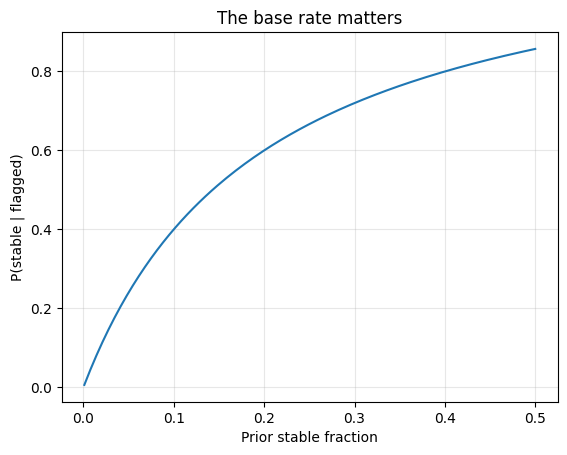

In [56]:
def posterior_positive(prior, sensitivity, false_positive_rate):
    true_positive = sensitivity * prior
    false_positive = false_positive_rate * (1 - prior)
    return true_positive / (true_positive + false_positive)

first = posterior_positive(0.05, 0.90, 0.15)
second = posterior_positive(first, 0.90, 0.15)
print(f"After one flag: {first:.4f}; after two: {second:.4f}")
assert np.isclose(first, 0.24)
priors = np.linspace(0.001, 0.5, 150)
plt.plot(priors, posterior_positive(priors, 0.9, 0.15))
plt.xlabel('Prior stable fraction'); plt.ylabel('P(stable | flagged)')
plt.title('The base rate matters'); plt.grid(alpha=0.3); plt.show()

**Try it yourself:** Change the prior to 0.01. Answer: approximately 0.05714. The second update assumes tests are independent **conditional on stability**, with the same class-conditional rates; rerunning the same deterministic filter is not new evidence.

In [57]:
prior = 0.01
third = posterior_positive(prior, 0.90, 0.15)
print(f"Prior: {prior}; Posterior after one flag: {third:.5f}")
assert np.isclose(third, 0.05714, 1e-4)

Prior: 0.01; Posterior after one flag: 0.05714


## 3. Update a distribution, not just a number

 with a Beta(a,b) prior, k successes in n trials give Beta(a+k,b+n−k). Its mean is a/(a+b).

Posterior parameters: 8 22
Prior mean: 0.2 Posterior mean: 0.26666666666666666


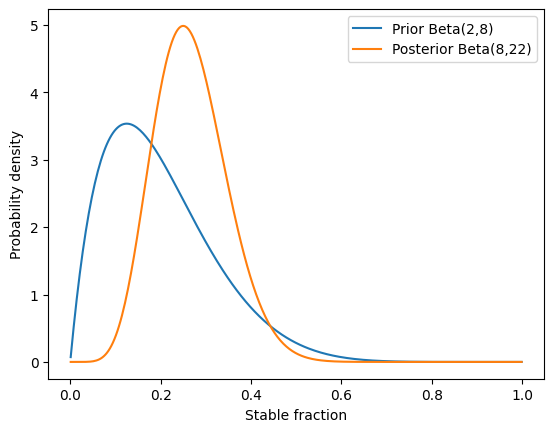

In [58]:
a, b = 2, 8
k, n = 6, 20
a_post, b_post = a + k, b + n - k
print('Posterior parameters:', a_post, b_post)
print('Prior mean:', a/(a+b), 'Posterior mean:', a_post/(a_post+b_post))
grid = np.linspace(0.001, 0.999, 300)
plt.plot(grid, beta.pdf(grid, a, b), label='Prior Beta(2,8)')
plt.plot(grid, beta.pdf(grid, a_post, b_post), label='Posterior Beta(8,22)')
plt.xlabel('Stable fraction'); plt.ylabel('Probability density')
plt.legend(); plt.show()

**Try it yourself:** Observe 1 more success in 10 new trials. Answer: Beta(9,31), mean 0.225. Do not add the old observations twice.

Posterior parameters: 9 31
Prior mean: 0.2 Posterior mean: 0.225


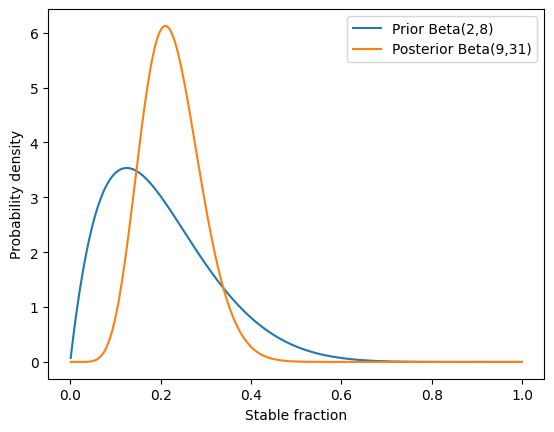

In [59]:
k, n = k+1, n+10
a_post, b_post = a + k, b + n - k
print('Posterior parameters:', a_post, b_post)
print('Prior mean:', a/(a+b), 'Posterior mean:', a_post/(a_post+b_post))

grid = np.linspace(0.001, 0.999, 300)
plt.plot(grid, beta.pdf(grid, a, b), label='Prior Beta(2,8)')
plt.plot(grid, beta.pdf(grid, a_post, b_post), label='Posterior Beta(9,31)')
plt.xlabel('Stable fraction'); plt.ylabel('Probability density')
plt.legend(); plt.show()

## 4. Discrete Naive Bayes scores

 multiply the prior by the likelihood of each **observed feature value**, then normalize across classes. The naive assumption is conditional independence given the class.

In [60]:
priors = np.array([2/3, 1/3])
# Columns: oxide, coordination number 6, density below 5 g/cm^3
likelihoods = np.array([[0.8, 0.5, 0.6], [0.3, 0.3, 0.4]])
scores = priors * np.prod(likelihoods, axis=1)
probabilities = scores / scores.sum()
print('Scores:', scores)
print('Probabilities [I, M]:', probabilities)
print('Prediction:', ['Insulator', 'Metal'][np.argmax(probabilities)])
assert np.isclose(probabilities[0], 40/43)

Scores: [0.16  0.012]
Probabilities [I, M]: [0.93023 0.06977]
Prediction: Insulator


**Try it yourself:** Replace oxide with not oxide by complementing only the first column. Answer: P(I|features) ≈ 0.58824.

In [61]:
likelihoods_new = likelihoods.copy()
likelihoods_new[:, 0] = 1 - likelihoods[:, 0]

scores_new = priors * np.prod(likelihoods_new, axis=1)
probabilities_new = scores_new / scores_new.sum()

print('New Scores:', scores_new)
print('New Probabilities [I, M]:', probabilities_new)
print('Prediction:', ['Insulator', 'Metal'][np.argmax(probabilities_new)])

assert np.isclose(probabilities_new[0], 0.58824, 1e-4)

New Scores: [0.04  0.028]
New Probabilities [I, M]: [0.58824 0.41176]
Prediction: Insulator


## 5. Avoid a zero likelihood
 Laplace smoothing adds one count to **every possible category**. For a binary feature the denominator becomes N+2.

In [62]:
def laplace(count, class_total, n_categories=2):
    return (count + 1) / (class_total + n_categories)

p_perovskite = np.array([laplace(10, 60), laplace(0, 30)])
scores = priors * p_perovskite * np.array([0.8, 0.3]) * np.array([0.6, 0.4])
print('Smoothed perovskite likelihoods [I, M]:', p_perovskite)
print('Posterior [I, M]:', scores / scores.sum())

Smoothed perovskite likelihoods [I, M]: [0.17742 0.03125]
Posterior [I, M]: [0.97846 0.02154]


**Try it yourself:** Use n_categories=3 for a different three-valued feature. Why must the denominator change? Here we smooth only the new perovskite likelihood; other likelihoods are supplied estimates.

In [63]:
p_perovskite = np.array([laplace(10, 60, 3), laplace(0, 30,3)])
scores = priors * p_perovskite * np.array([0.8, 0.3]) * np.array([0.6, 0.4])
print('Smoothed perovskite likelihoods [I, M]:', p_perovskite)
print('Posterior [I, M]:', scores / scores.sum())

print("The denominator must chnage because Laplace adds a smoothening count of +1 to every category.\n\
So we ensure that the smoothed probabilities across all categories will still sum to 1, by adding 1 to the denominator.")

Smoothed perovskite likelihoods [I, M]: [0.1746 0.0303]
Posterior [I, M]: [0.97877 0.02123]
The denominator must chnage because Laplace adds a smoothening count of +1 to every category.
So we ensure that the smoothed probabilities across all categories will still sum to 1, by adding 1 to the denominator.


## 6. Gaussian densities and classification

continuous descriptors use Gaussian densities. Each row below is a class, each column a feature: density (g/cm³), atomic size (Å), electronegativity difference.

In [64]:
means = np.array([[4.0, 1.3, 2.1], [4.0, 0.6, 0.4]])
stds = np.array([[2.0, 0.2, 0.4], [2.0, 0.2, 0.3]])
x = np.array([3.0, 0.9, 1.5])
def gaussian_pdf(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2) / (sigma*np.sqrt(2*np.pi))
z = (x - means) / stds
heights = gaussian_pdf(x, means, stds)
scores = priors * np.prod(heights, axis=1)
print('z-scores:\n', z)
print('Densities:\n', heights)
print('Posterior [I, M]:', scores/scores.sum())
assert np.isclose((scores/scores.sum())[0], 0.994, atol=0.001)

z-scores:
 [[-0.5     -2.      -1.5    ]
 [-0.5      1.5      3.66667]]
Densities:
 [[0.17603 0.26995 0.32379]
 [0.17603 0.64759 0.0016 ]]
Posterior [I, M]: [0.9941 0.0059]


**Try it yourself:** Use x=[5.0,0.7,0.6]. P(I|x) is approximately 2.08e-5. Explain why a density greater than one is valid. Identical density-feature distributions contribute no class discrimination.

In [65]:
x_new = np.array([5.0, 0.7, 0.6])

heights_new = gaussian_pdf(x_new, means, stds)
scores_new = priors * np.prod(heights_new, axis=1)
probabilities_new = scores_new / scores_new.sum()

print("Densities at x_new:\n", heights_new)
print(f"Posterior probabilities [I, M]: {probabilities_new}")
print(f"P(I|x_new): {probabilities_new[0]:.7e}")

assert np.isclose(probabilities_new[0], 2.08e-5, 1e-2)

print("\nExplanation:")
print("A probability density greater than 1 is valid because it represents a density, not a probability.\n\
The total integrated area under the probability density curve must equal 1, but the height can be arbitrary.\n\
If a distribution is narrow (small standard deviation), the density must be high to maintain a total area of 1.")

Densities at x_new:
 [[0.17603 0.02216 0.00088]
 [0.17603 1.76033 1.06483]]
Posterior probabilities [I, M]: [0.00002 0.99998]
P(I|x_new): 2.0841101e-05

Explanation:
A probability density greater than 1 is valid because it represents a density, not a probability.
The total integrated area under the probability density curve must equal 1, but the height can be arbitrary.
If a distribution is narrow (small standard deviation), the density must be high to maintain a total area of 1.


## 7. Stable calculations with logarithms
 log score = log prior + sum of log densities. Subtracting the largest log score before exponentiation prevents numerical underflow during normalization.

In [66]:
def normalize_log_scores(log_scores):
    shifted = log_scores - np.max(log_scores)
    weights = np.exp(shifted)
    return weights / weights.sum()

def gaussian_log_scores(x, means, stds, priors):
    log_densities = -np.log(stds*np.sqrt(2*np.pi)) - 0.5*((x-means)/stds)**2
    return np.log(priors) + np.sum(log_densities, axis=1)

print('Direct exponentials:', np.exp(np.array([-1000.0, -1002.0])))
print('Stable probabilities:', normalize_log_scores(np.array([-1000.0, -1002.0])))
log_scores = gaussian_log_scores(x, means, stds, priors)
assert np.allclose(normalize_log_scores(log_scores), scores/scores.sum())

Direct exponentials: [0. 0.]
Stable probabilities: [0.8808 0.1192]


**Try it yourself:** Add 5000 to both log scores. The probabilities stay the same because only relative scores matter.

In [67]:
original_probs = normalize_log_scores(log_scores)
shifted_log_scores = log_scores + 5000
shifted_probs = normalize_log_scores(shifted_log_scores)

print("Original probabilities:", original_probs)
print("Shifted probabilities:", shifted_probs)
assert np.allclose(original_probs, shifted_probs)

Original probabilities: [0.9941 0.0059]
Shifted probabilities: [0.9941 0.0059]


## 8. Train GaussianNB on a small dataset

This extension connects the PDF to a machine-learning workflow. Split before fitting. The generated classes are deliberately simple; a high score here does not demonstrate real chemical predictive power.

In [68]:
# Synthetic descriptors only: no experimental or DFT data.
rng = np.random.default_rng(42)
X_I = rng.normal([4.0, 1.3, 2.1], [0.6, 0.25, 0.4], size=(60, 3))
X_M = rng.normal([4.0, 0.6, 0.4], [0.6, 0.25, 0.3], size=(30, 3))
X = np.vstack([X_I, X_M])
y = np.array(['Insulator']*60 + ['Metal']*30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=7, stratify=y)
print('Train/test shapes:', X_train.shape, X_test.shape)
model = GaussianNB()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Class order:', model.classes_)
print('Training class means:\n', model.theta_)
print('Test accuracy:', accuracy_score(y_test, pred))
print('Confusion matrix (rows=true, columns=predicted):')
print(confusion_matrix(y_test, pred, labels=model.classes_))
print('New-material probabilities:', model.predict_proba([[3, 0.9, 1.5]]))
assert np.allclose(model.predict_proba(X_test).sum(axis=1), 1)

Train/test shapes: (60, 3) (30, 3)
Class order: ['Insulator' 'Metal']
Training class means:
 [[3.95804 1.26188 2.07217]
 [3.90805 0.63337 0.38732]]
Test accuracy: 1.0
Confusion matrix (rows=true, columns=predicted):
[[20  0]
 [ 0 10]]
New-material probabilities: [[0.91696 0.08304]]


**Try it yourself:** Calculate each class mean yourself with X_train[y_train == label].mean(axis=0). For the maximum-likelihood variance use var(axis=0, ddof=0); sklearn also adds a small variance-stabilizing term. Never estimate model parameters from test labels.

In [69]:
for label in ['Insulator', 'Metal']:
    X_class = X_train[y_train == label]
    class_mean = X_class.mean(axis=0)
    class_var = X_class.var(axis=0, ddof=0)
    print(f"{label} - Manual Mean: {class_mean}")
    print(f"{label} - Manual Variance: {class_var}\n")

Insulator - Manual Mean: [3.95804 1.26188 2.07217]
Insulator - Manual Variance: [0.22127 0.03954 0.10699]

Metal - Manual Mean: [3.90805 0.63337 0.38732]
Metal - Manual Variance: [0.3546  0.07222 0.13256]

